# CIFAR-10 Data Exploration

This notebook explores the CIFAR-10 dataset before training the baseline CNN.  
The goal is to understand the dataset structure, class distribution, image characteristics, and preprocessing requirements.

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.5.1
Torchvision version: 0.20.1
CUDA available: True


In [10]:
# Convert PIL images to PyTorch tensors with pixel values scaled to [0, 1]
transform = transforms.ToTensor()

# Load CIFAR-10 training and test sets
train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


In [11]:
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Image shape: torch.Size([3, 32, 32])
Label: 6
Class: frog


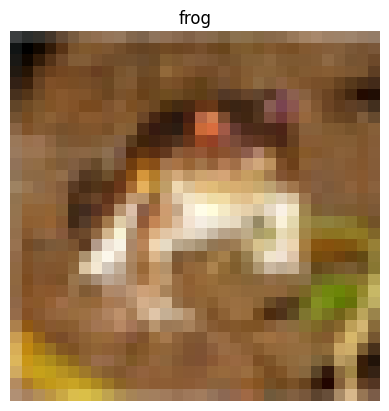

In [16]:
# Inspect and visualize one training sample
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.classes[label])

# Rearrange from [C, H, W] to [H, W, C] for Matplotlib
plt.imshow(image.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

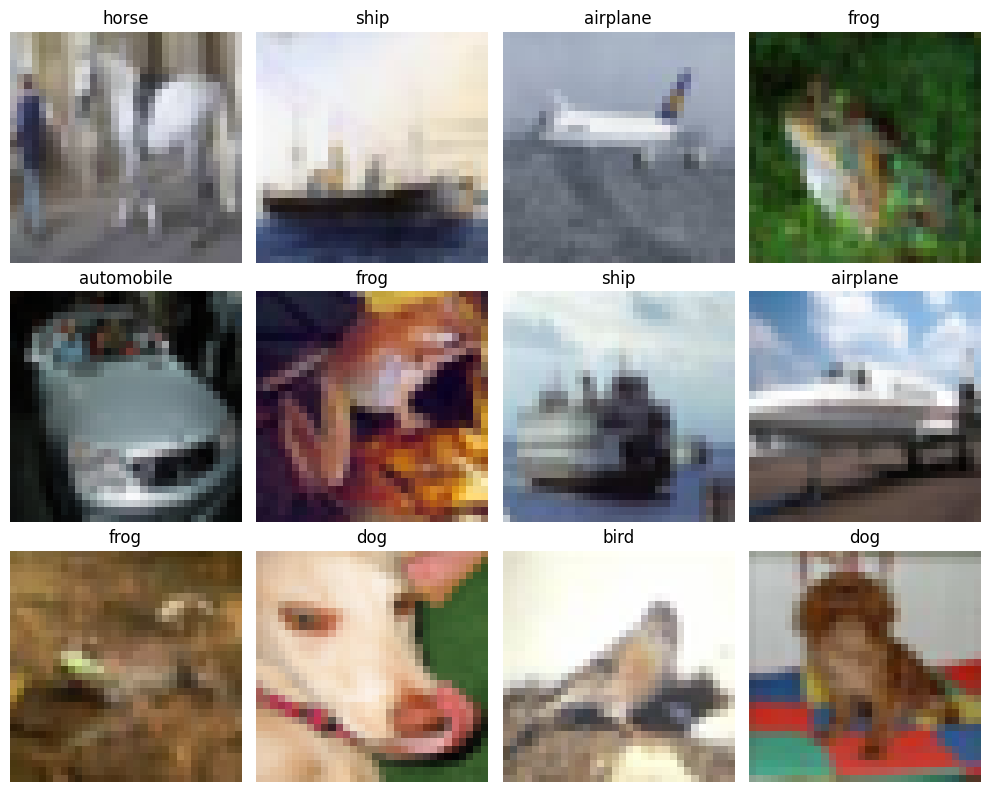

In [17]:
# Visualize random training samples
np.random.seed(42)
indices = np.random.choice(len(train_dataset), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, idx in zip(axes.flat, indices):
    image, label = train_dataset[idx]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Check class distribution
train_counts = np.bincount(train_dataset.targets)
test_counts = np.bincount(test_dataset.targets)

for class_name, train_count, test_count in zip(
    train_dataset.classes, train_counts, test_counts
):
    print(
        f"{class_name:10s} | "
        f"Train: {train_count:4d} | "
        f"Test: {test_count:4d} | "
    )

airplane   | Train: 5000 | Test: 1000 | 
automobile | Train: 5000 | Test: 1000 | 
bird       | Train: 5000 | Test: 1000 | 
cat        | Train: 5000 | Test: 1000 | 
deer       | Train: 5000 | Test: 1000 | 
dog        | Train: 5000 | Test: 1000 | 
frog       | Train: 5000 | Test: 1000 | 
horse      | Train: 5000 | Test: 1000 | 
ship       | Train: 5000 | Test: 1000 | 
truck      | Train: 5000 | Test: 1000 | 


In [27]:
from torch.utils.data import DataLoader

# Compute pixel statistics from the training set
stats_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=False
)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
pixel_count = 0

pixel_min = float("inf")
pixel_max = float("-inf")

for images, _ in stats_loader:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))

    pixel_count += images.size(0) * images.size(2) * images.size(3)

    pixel_min = min(pixel_min, images.min().item())
    pixel_max = max(pixel_max, images.max().item())

channel_mean = channel_sum / pixel_count
channel_std = torch.sqrt(
    channel_squared_sum / pixel_count - channel_mean ** 2
)

print("Pixel range:", (pixel_min, pixel_max))
print("Channel mean:", channel_mean)
print("Channel std:", channel_std)

Pixel range: (0.0, 1.0)
Channel mean: tensor([0.4914, 0.4822, 0.4465])
Channel std: tensor([0.2470, 0.2435, 0.2616])
